### UMAP for Data Integration

Here we will overlap graphs from single cell RNAseq and Proteomics data sets from the CITE-seq technology, and produce a consensus / integrative OMICs UMAP plot. The idea is to convert the two data types into graphs, i.e. non-parametric space where they forget their technological differences, and overlap the graphs. The resulting graph will be used for constructing the UMAP embeddings.

![UMAP_DataIntegration](lab/assests/UMAP_DataIntegration.png)

We will start with reading and log-transforming the OMICs data.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# https://github.com/NikolayOskolkov/DeepLearningDataIntegration/blob/master/scRNAseq.txt
# https://github.com/NikolayOskolkov/DeepLearningDataIntegration/blob/master/scProteomics.txt

scRNAseq = pd.read_csv('scRNAseq.txt',sep='\t')
scProteomics = pd.read_csv('scProteomics.txt',sep='\t')

X_scRNAseq = scRNAseq.values[:,0:(scRNAseq.shape[1]-1)]
Y_scRNAseq = scRNAseq.values[:,scRNAseq.shape[1]-1]
X_scProteomics = scProteomics.values[:,0:(scProteomics.shape[1]-1)]
Y_scProteomics = scProteomics.values[:,scProteomics.shape[1]-1]

X_scRNAseq = np.log(X_scRNAseq + 1)
X_scProteomics = np.log(X_scProteomics + 1)

In [3]:
X_scRNAseq.shape

(8617, 976)

In [4]:
X_scProteomics.shape

(8617, 10)

Let us display the UMAP embeddings of individual OMICs data sets. We will start with the scRNAseq dataset. As an optimal number of nearest neighbors we will choose $\sqrt{N} = \sqrt{8617} = 93$.

2025-05-26 12:28:00.535130: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-26 12:28:00.780691: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748251680.880255 1965495 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748251680.910672 1965495 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-26 12:28:01.164444: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

UMAP(init=array([[45.31235894, 0.07477159],
       [46.53271754, 1.71486063],
       [46.8638235 , 0.98846408],
       ...,
       [ 1.11426643, -1.86512337],
       [ 4.54796886, -0.69171758],
       [ 2.61794017, -0.97065852]]), min_dist=1, n_epochs=1000, n_neighbors=93, verbose=2)
Mon May 26 12:28:06 2025 Construct fuzzy simplicial set
Mon May 26 12:28:06 2025 Finding Nearest Neighbors
Mon May 26 12:28:06 2025 Building RP forest with 10 trees
Mon May 26 12:28:13 2025 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	 3  /  13
	Stopping threshold met -- exiting after 3 iterations
Mon May 26 12:28:40 2025 Finished Nearest Neighbor Search
Mon May 26 12:28:44 2025 Construct embedding


Epochs completed:   0%|            0/1000 [00:00]

	completed  0  /  1000 epochs
	completed  100  /  1000 epochs
	completed  200  /  1000 epochs
	completed  300  /  1000 epochs
	completed  400  /  1000 epochs
	completed  500  /  1000 epochs
	completed  600  /  1000 epochs
	completed  700  /  1000 epochs
	completed  800  /  1000 epochs
	completed  900  /  1000 epochs
Mon May 26 12:29:10 2025 Finished embedding


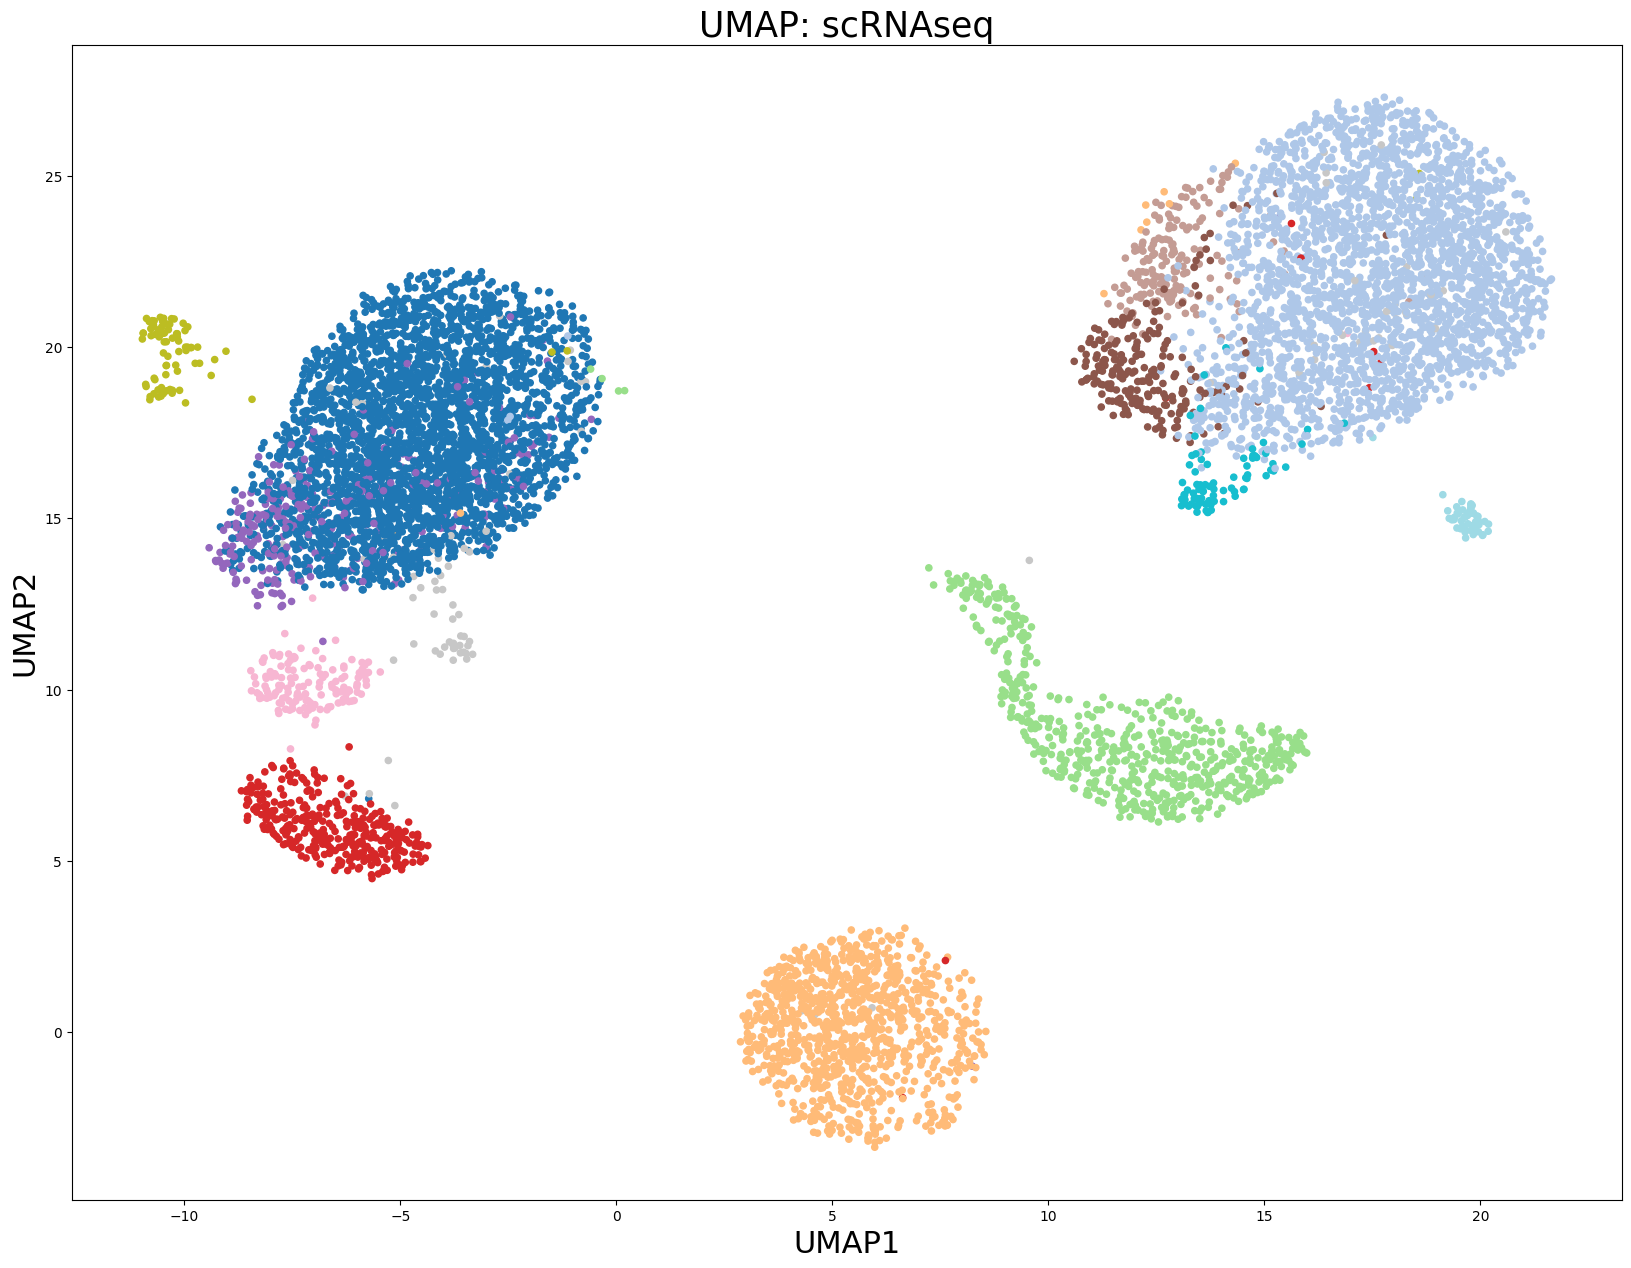

In [5]:
import warnings
warnings.filterwarnings("ignore")

from umap import UMAP
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

X_reduced = PCA(n_components = 20).fit_transform(X_scRNAseq)
model = UMAP(n_components = 2, min_dist = 1, n_neighbors = 93, init = X_reduced[:, 0:2], n_epochs = 1000, 
             verbose = 2)
umap = model.fit_transform(X_reduced)

plt.figure(figsize = (20,15))
plt.scatter(umap[:, 0], umap[:, 1], c = Y_scRNAseq, cmap = 'tab20', s = 20)
plt.title('UMAP: scRNAseq', fontsize = 25); 
plt.xlabel("UMAP1", fontsize = 22); plt.ylabel("UMAP2", fontsize = 22)
plt.show()

Now let us display UMAP embeddings for the scProteomics dataset of the CITE-seq sequencing technology.

UMAP(init=array([[-1.65366402, -0.2564025 ],
       [-1.7084814 , 1.69115812],
       [-1.03060202, -0.13172222],
       ...,
       [-2.19859839, -5.16795233],
       [-2.10143214, -2.48594223],
       [-2.43134931, -3.33697131]]), min_dist=0.8, n_epochs=1000, n_neighbors=93, verbose=2)
Mon May 26 12:29:21 2025 Construct fuzzy simplicial set
Mon May 26 12:29:21 2025 Finding Nearest Neighbors
Mon May 26 12:29:21 2025 Building RP forest with 10 trees
Mon May 26 12:29:21 2025 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	Stopping threshold met -- exiting after 2 iterations
Mon May 26 12:29:25 2025 Finished Nearest Neighbor Search
Mon May 26 12:29:26 2025 Construct embedding


Epochs completed:   0%|            0/1000 [00:00]

	completed  0  /  1000 epochs
	completed  100  /  1000 epochs
	completed  200  /  1000 epochs
	completed  300  /  1000 epochs
	completed  400  /  1000 epochs
	completed  500  /  1000 epochs
	completed  600  /  1000 epochs
	completed  700  /  1000 epochs
	completed  800  /  1000 epochs
	completed  900  /  1000 epochs
Mon May 26 12:29:49 2025 Finished embedding


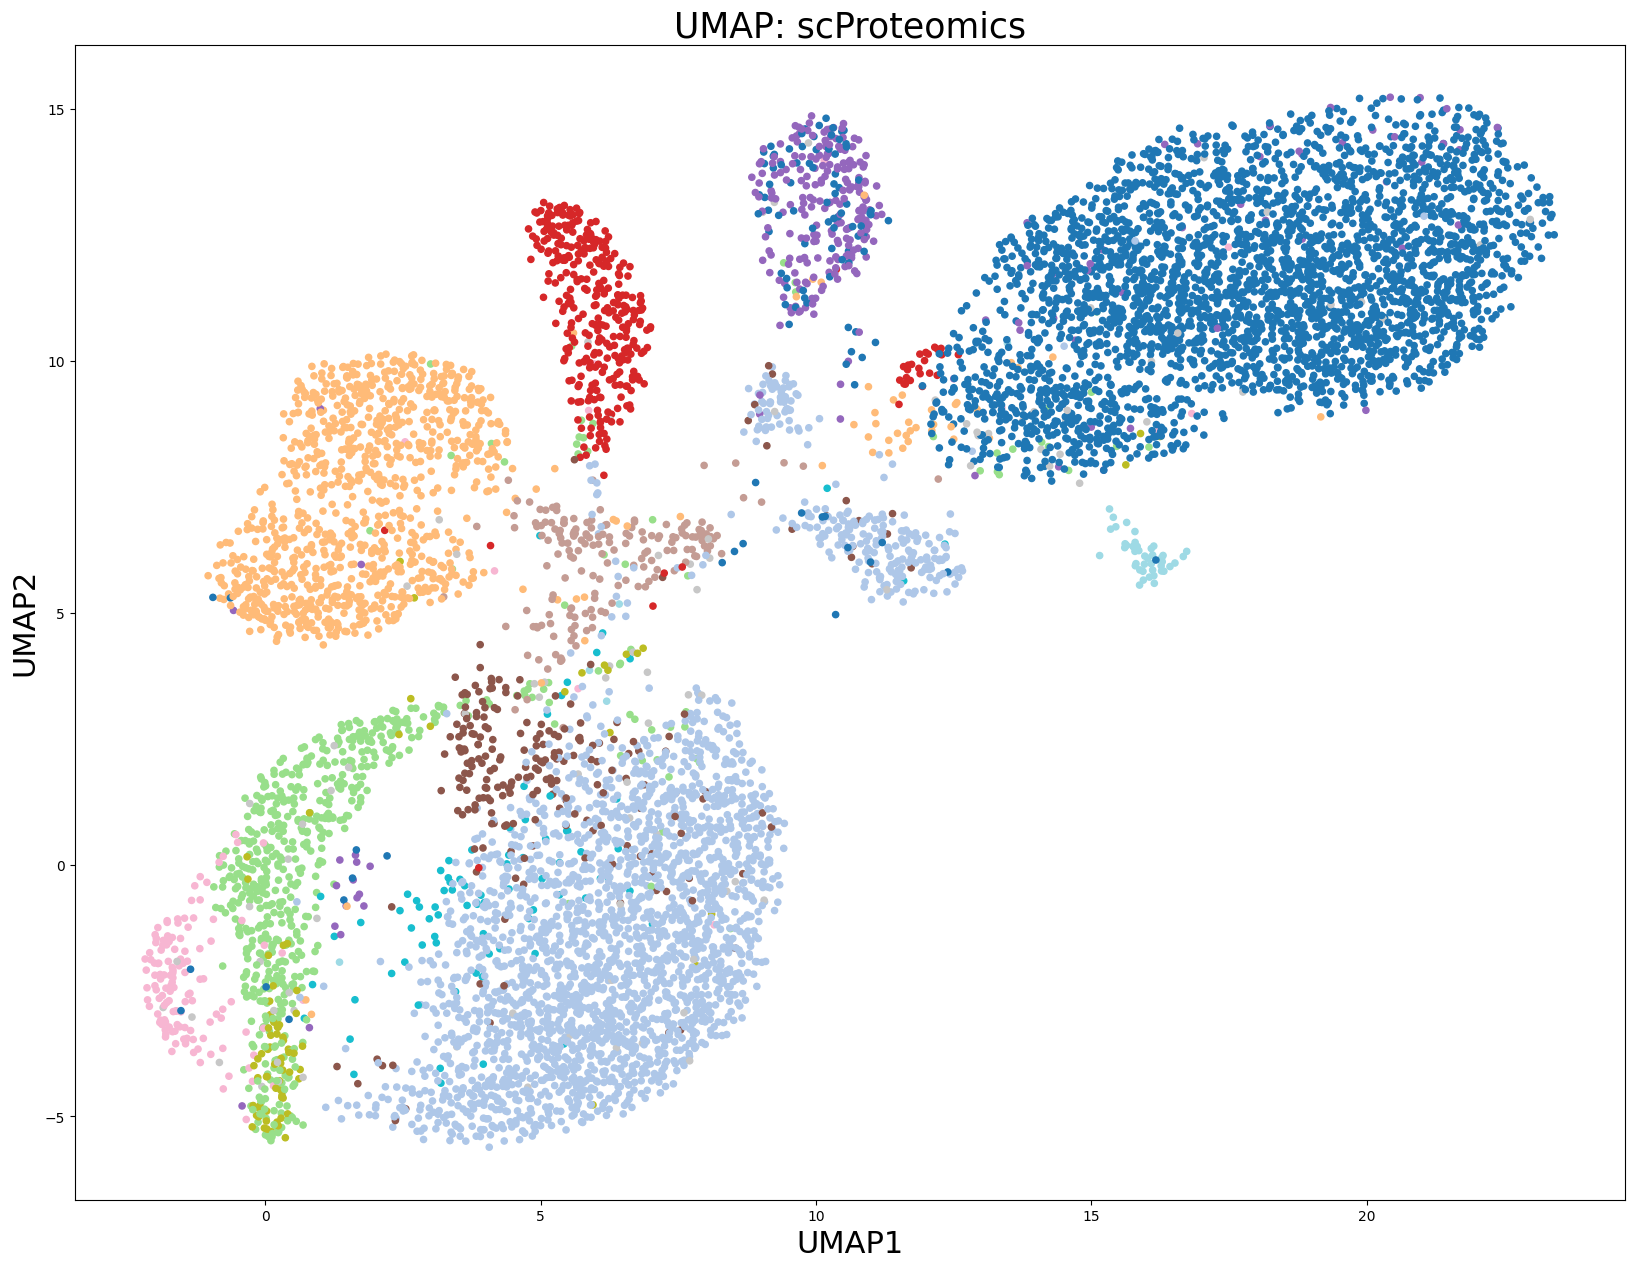

In [6]:
import warnings
warnings.filterwarnings("ignore")

from umap import UMAP
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

X_reduced = PCA(n_components = 10).fit_transform(X_scProteomics)
model = UMAP(n_components = 2, min_dist = 0.8, n_neighbors = 93, init = X_reduced[:, 0:2], n_epochs = 1000, 
             verbose = 2)
umap = model.fit_transform(X_reduced)

plt.figure(figsize = (20,15))
plt.scatter(umap[:, 0], umap[:, 1], c = Y_scProteomics, cmap = 'tab20', s = 20)
plt.title('UMAP: scProteomics', fontsize = 25); 
plt.xlabel("UMAP1", fontsize = 22); plt.ylabel("UMAP2", fontsize = 22)
plt.show()

Now we will construct the intersection of the two graphs / simplicial sets, and visualize the resulting embeddings.

In [7]:
import umap

X_reduced_scRNAseq = PCA(n_components = 20).fit_transform(X_scRNAseq)
X_reduced_scProteomics = PCA(n_components = 10).fit_transform(X_scProteomics)

fit1 = umap.UMAP(n_components = 2, min_dist = 1, n_neighbors = 93, n_epochs = 1000, 
                 init = X_reduced_scRNAseq[:, 0:2], verbose = 2).fit(X_reduced_scRNAseq)
fit2 = umap.UMAP(n_components = 2, min_dist = 0.8, n_neighbors = 93, n_epochs = 1000, 
                 init = X_reduced_scProteomics[:, 0:2], verbose = 2).fit(X_reduced_scProteomics)
intersection = umap.umap_. general_simplicial_set_intersection(fit1.graph_, fit2.graph_, weight = 0.45)
intersection = umap.umap_.reset_local_connectivity(intersection)
embedding = umap.umap_.simplicial_set_embedding(fit1._raw_data, intersection, fit1.n_components, 
                                                fit1.learning_rate, fit1._a, fit1._b, 
                                                fit1.repulsion_strength, fit1.negative_sample_rate, 
                                                1000, 'random', np.random, fit1.metric, 
                                                fit1._metric_kwds, False, densmap_kwds=False, output_dens=False)

UMAP(init=array([[45.31235894, 0.07477159],
       [46.53271754, 1.71486063],
       [46.8638235 , 0.98846408],
       ...,
       [ 1.11426643, -1.86512337],
       [ 4.54796886, -0.69171758],
       [ 2.61794017, -0.97065852]]), min_dist=1, n_epochs=1000, n_neighbors=93, verbose=2)
Mon May 26 12:30:00 2025 Construct fuzzy simplicial set
Mon May 26 12:30:00 2025 Finding Nearest Neighbors
Mon May 26 12:30:00 2025 Building RP forest with 10 trees
Mon May 26 12:30:00 2025 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	 3  /  13
	Stopping threshold met -- exiting after 3 iterations
Mon May 26 12:30:04 2025 Finished Nearest Neighbor Search
Mon May 26 12:30:05 2025 Construct embedding


Epochs completed:   0%|            0/1000 [00:00]

	completed  0  /  1000 epochs
	completed  100  /  1000 epochs
	completed  200  /  1000 epochs
	completed  300  /  1000 epochs
	completed  400  /  1000 epochs
	completed  500  /  1000 epochs
	completed  600  /  1000 epochs
	completed  700  /  1000 epochs
	completed  800  /  1000 epochs
	completed  900  /  1000 epochs
Mon May 26 12:30:28 2025 Finished embedding
UMAP(init=array([[-1.65366402, -0.2564025 ],
       [-1.7084814 , 1.69115812],
       [-1.03060202, -0.13172222],
       ...,
       [-2.19859839, -5.16795233],
       [-2.10143214, -2.48594223],
       [-2.43134931, -3.33697131]]), min_dist=0.8, n_epochs=1000, n_neighbors=93, verbose=2)
Mon May 26 12:30:28 2025 Construct fuzzy simplicial set
Mon May 26 12:30:28 2025 Finding Nearest Neighbors
Mon May 26 12:30:28 2025 Building RP forest with 10 trees
Mon May 26 12:30:28 2025 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	Stopping threshold met -- exiting after 2 iterations
Mon May 26 12:30:32 2025 Finished Nearest Neighbor Sea

Epochs completed:   0%|            0/1000 [00:00]

	completed  0  /  1000 epochs
	completed  100  /  1000 epochs
	completed  200  /  1000 epochs
	completed  300  /  1000 epochs
	completed  400  /  1000 epochs
	completed  500  /  1000 epochs
	completed  600  /  1000 epochs
	completed  700  /  1000 epochs
	completed  800  /  1000 epochs
	completed  900  /  1000 epochs
Mon May 26 12:30:56 2025 Finished embedding


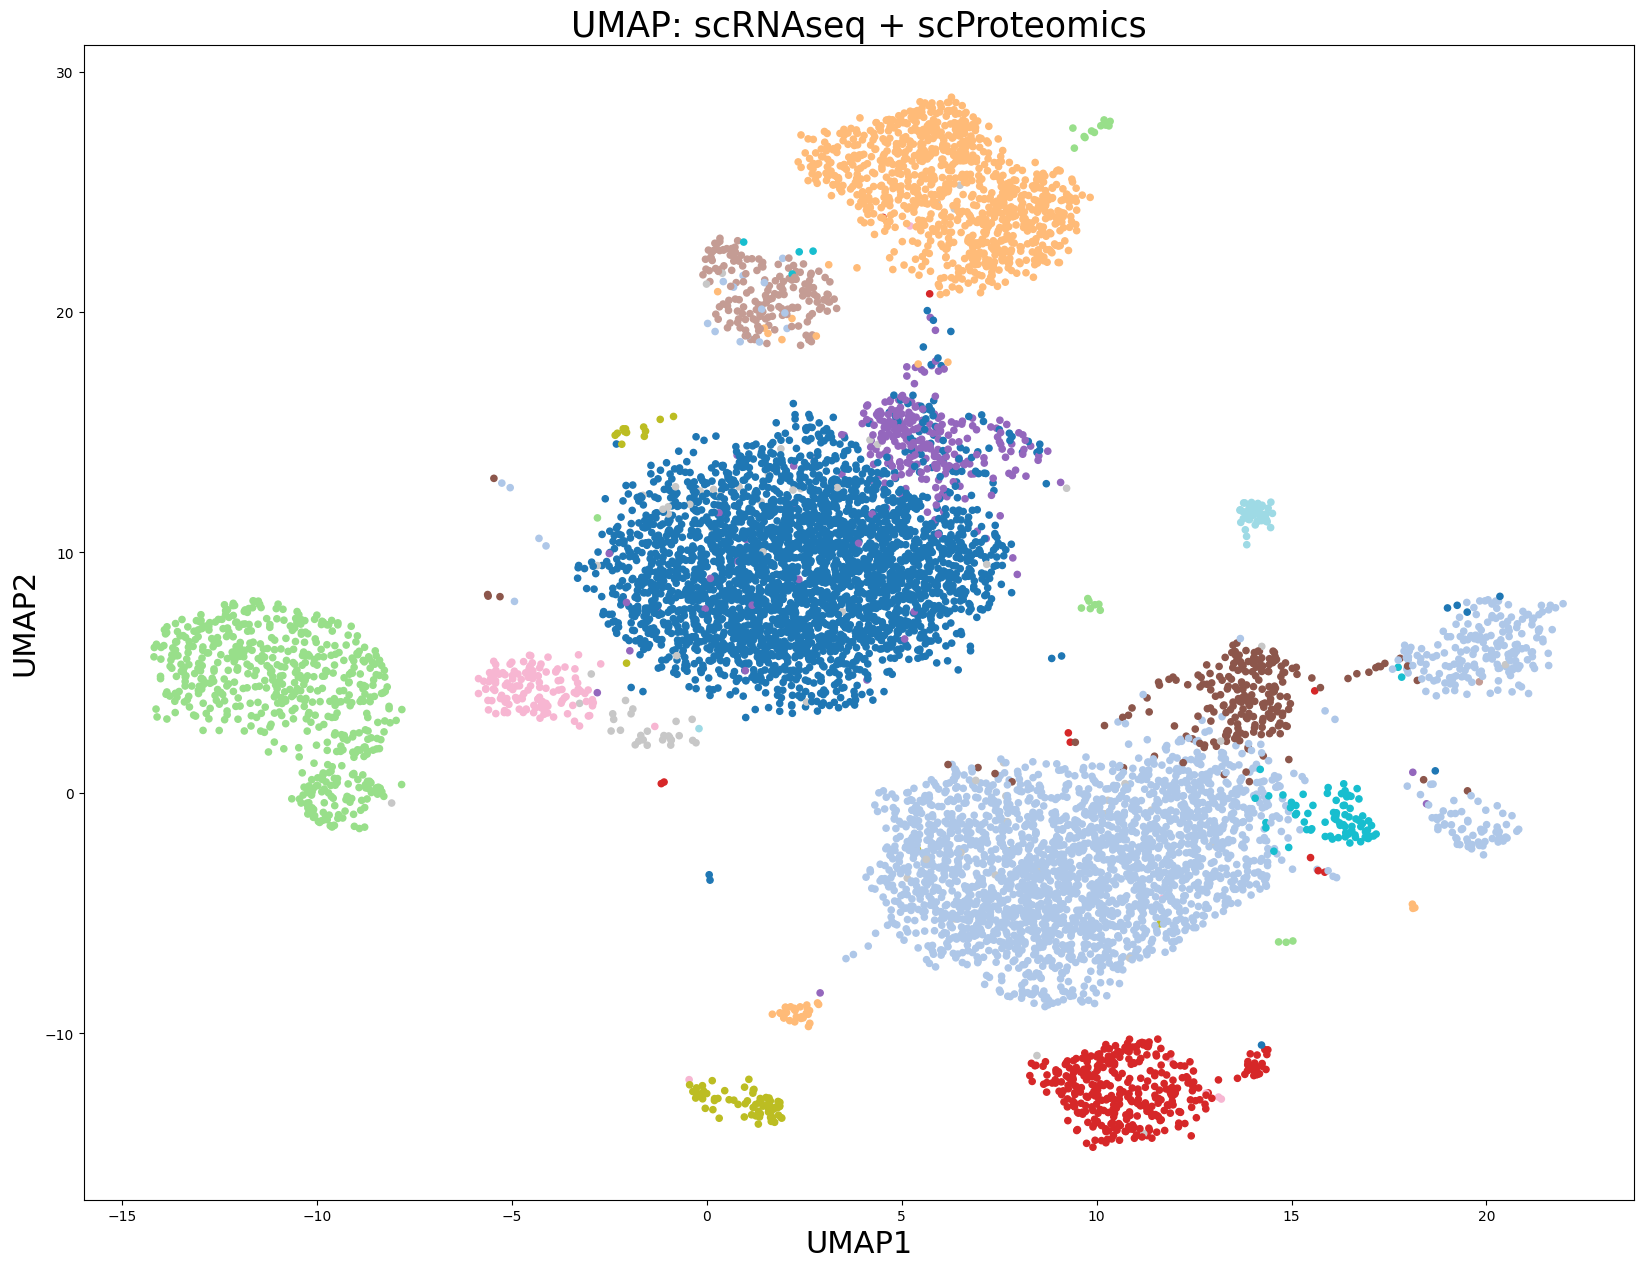

In [8]:
plt.figure(figsize = (20,15))
plt.scatter(embedding[0][:, 0], embedding[0][:, 1], c = Y_scRNAseq, cmap = 'tab20', s = 20)
plt.title('UMAP: scRNAseq + scProteomics', fontsize = 25); 
plt.xlabel("UMAP1", fontsize = 22); plt.ylabel("UMAP2", fontsize = 22)
plt.show()